In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="")
project = rf.workspace("helmetdetection-bolsj").project("helmet_detection-jctve")
version = project.version(1)
dataset = version.download("yolov12")


loading Roboflow workspace...
loading Roboflow project...


In [2]:
dataset.location

'/home/syssoni/Documents/Python/helmet_detection/yolov12/helmet_detection-1'

In [3]:
!nvidia-smi

Mon Mar 31 14:53:29 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.120                Driver Version: 550.120        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   47C    P0             11W /   60W |       8MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.96 🚀 Python-3.13.2 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3895MiB)
Setup complete ✅ (12 CPUs, 15.0 GB RAM, 32.1/61.2 GB disk)


In [5]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())


True
1


In [10]:
from ultralytics import YOLO


model = YOLO("yolo12n.pt")
torch.cuda.empty_cache()

train_results = model.train(
    data="/home/syssoni/Documents/Python/helmet_detection/yolov12/helmet_detection-1/data.yaml",  # path to dataset YAML
    imgsz = 640, # training image size
    device ="0",  # device to run on, i.e. device=0 or device=0,1,2,3 or device=cpu
    amp = True,
    patience = 20
)

New https://pypi.org/project/ultralytics/8.3.99 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.96 🚀 Python-3.13.2 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3895MiB)
engine/trainer: task=detect, mode=train, model=yolo12n.pt, data=/home/syssoni/Documents/Python/helmet_detection/yolov12/helmet_detection-1/data.yaml, epochs=100, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train10, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_

train: Scanning /home/syssoni/Documents/Python/helmet_detection/yolov12/helmet_detection-1/train/labels.cache... 1536 images, 22 backgrounds, 0 corrupt: 100%|██████████| 1536/1536 [00:00<?, ?it/s]
val: Scanning /home/syssoni/Documents/Python/helmet_detection/yolov12/helmet_detection-1/valid/labels.cache... 146 images, 0 backgrounds, 0 corrupt: 100%|██████████| 146/146 [00:00<?, ?it/s]


Plotting labels to runs/detect/train10/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 113 weight(decay=0.0), 120 weight(decay=0.0005), 119 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/detect/train10
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      1/100      3.46G      1.967      3.418      1.597         45        640: 100%|██████████| 96/96 [00:32<00:00,  2.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<00:00,  1.83it/s]


                   all        146        338      0.368      0.171      0.142     0.0487

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

     39/100      3.41G      1.612      1.372       1.48         39        640: 100%|██████████| 96/96 [00:27<00:00,  3.49it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  4.96it/s]

                   all        146        338      0.619      0.541      0.548      0.277
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 19, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



39 epochs completed in 0.326 hours.
Optimizer stripped from runs/detect/train10/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train10/weights/best.pt, 5.5MB

Validating runs/detect/train10/weights/best.pt...
Ultralytics 8.3.96 🚀 Python-3.13.2 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3895MiB)
YOLOv12n summary (fused): 159 layers, 2,557,118 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  3.17it/s]


                   all        146        338      0.557      0.549      0.545      0.277
                helmet        106        219      0.545      0.744      0.683      0.394
        without helmet         61        119      0.569      0.353      0.406       0.16
Speed: 0.5ms preprocess, 5.6ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/train10


TRAINING RESULTS

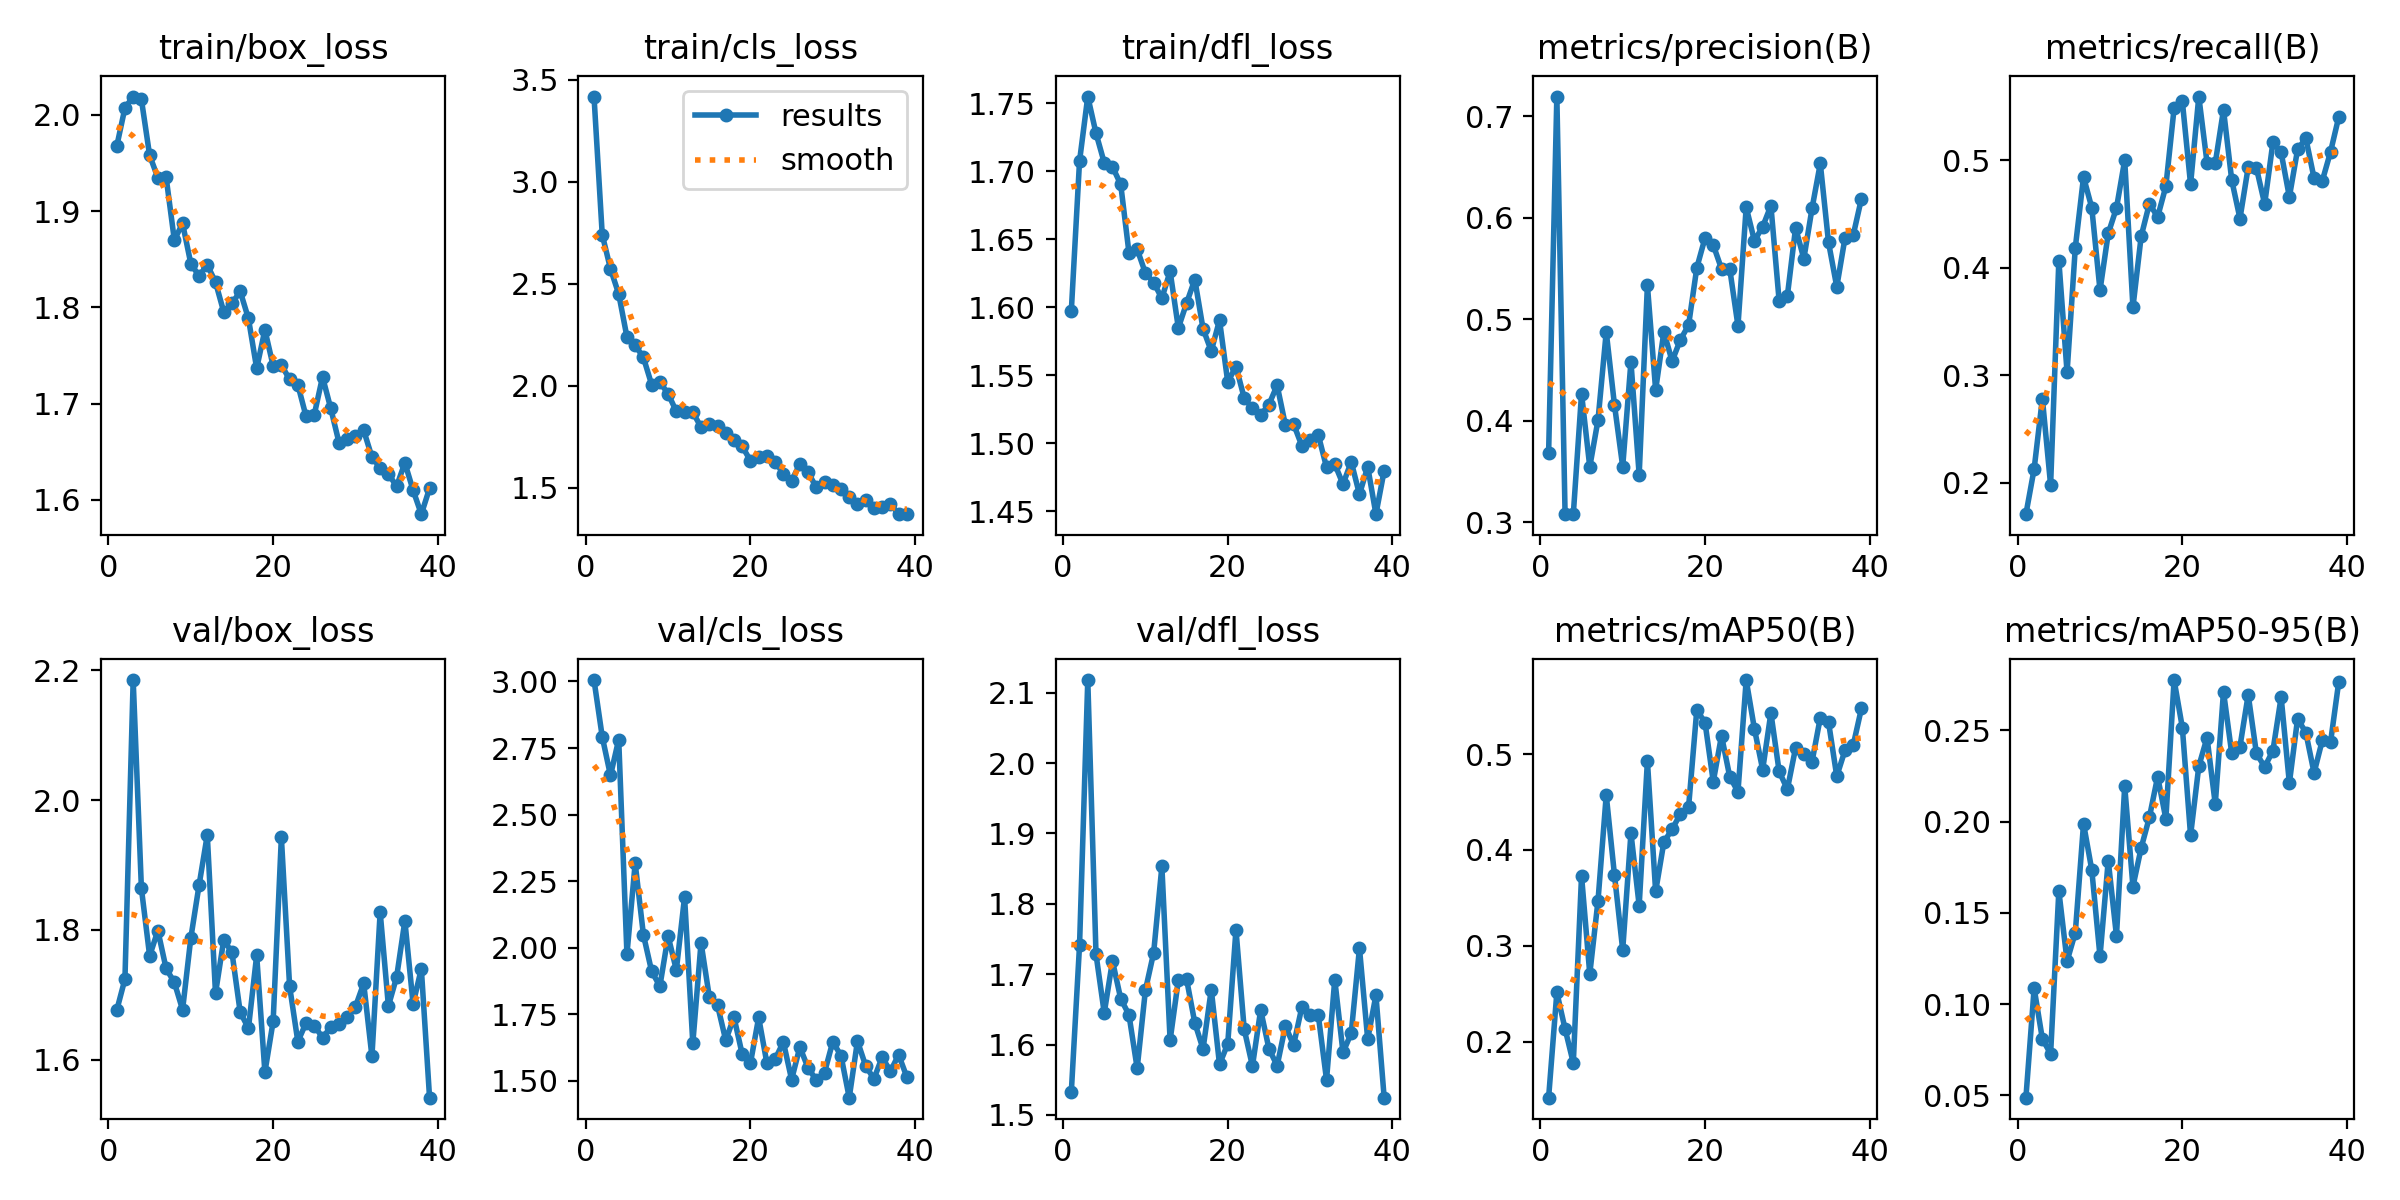

In [8]:
from IPython.display import Image, Markdown

display(Markdown("TRAINING RESULTS"))
Image("/home/syssoni/Documents/Python/helmet_detection/yolov12/runs/detect/train10/results.png", width=1000, height=1000)

TRAINING: Confusion Matrix

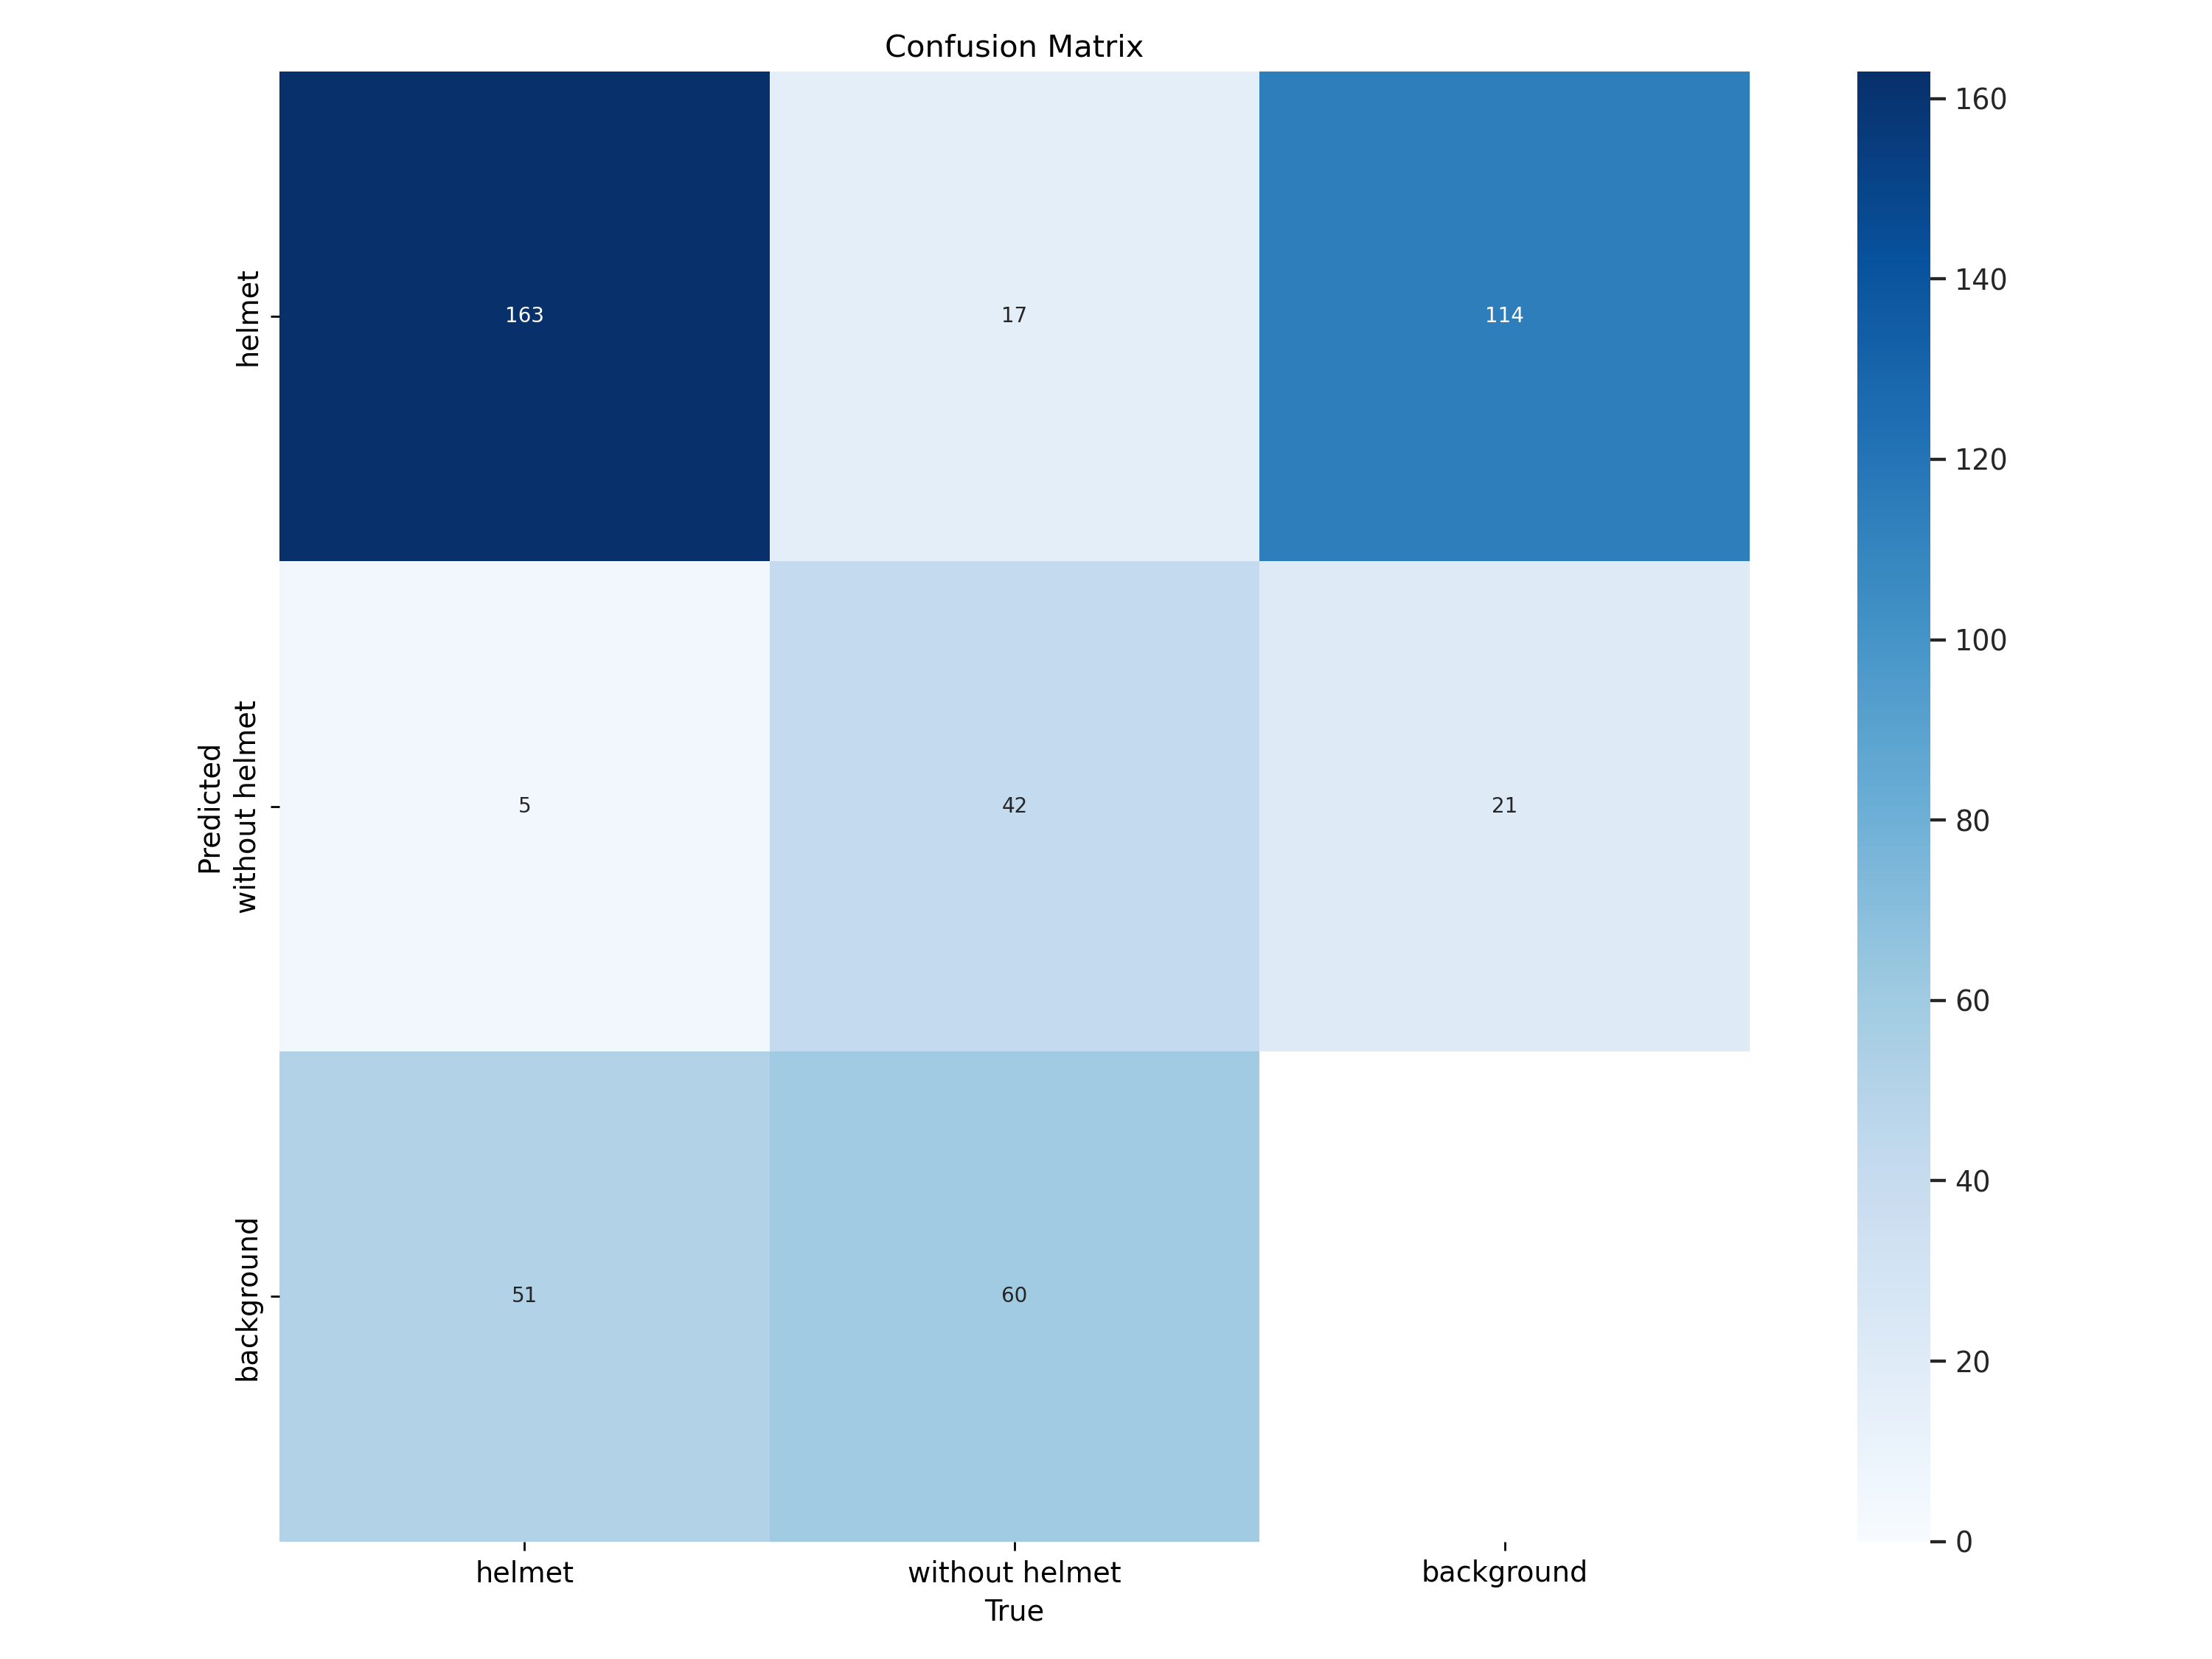

In [12]:
display(Markdown("TRAINING: Confusion Matrix"))
Image("/home/syssoni/Documents/Python/helmet_detection/yolov12/runs/detect/train10/confusion_matrix.png", width=800, height=800)

TRAINING: Confusion Matrix Normalised

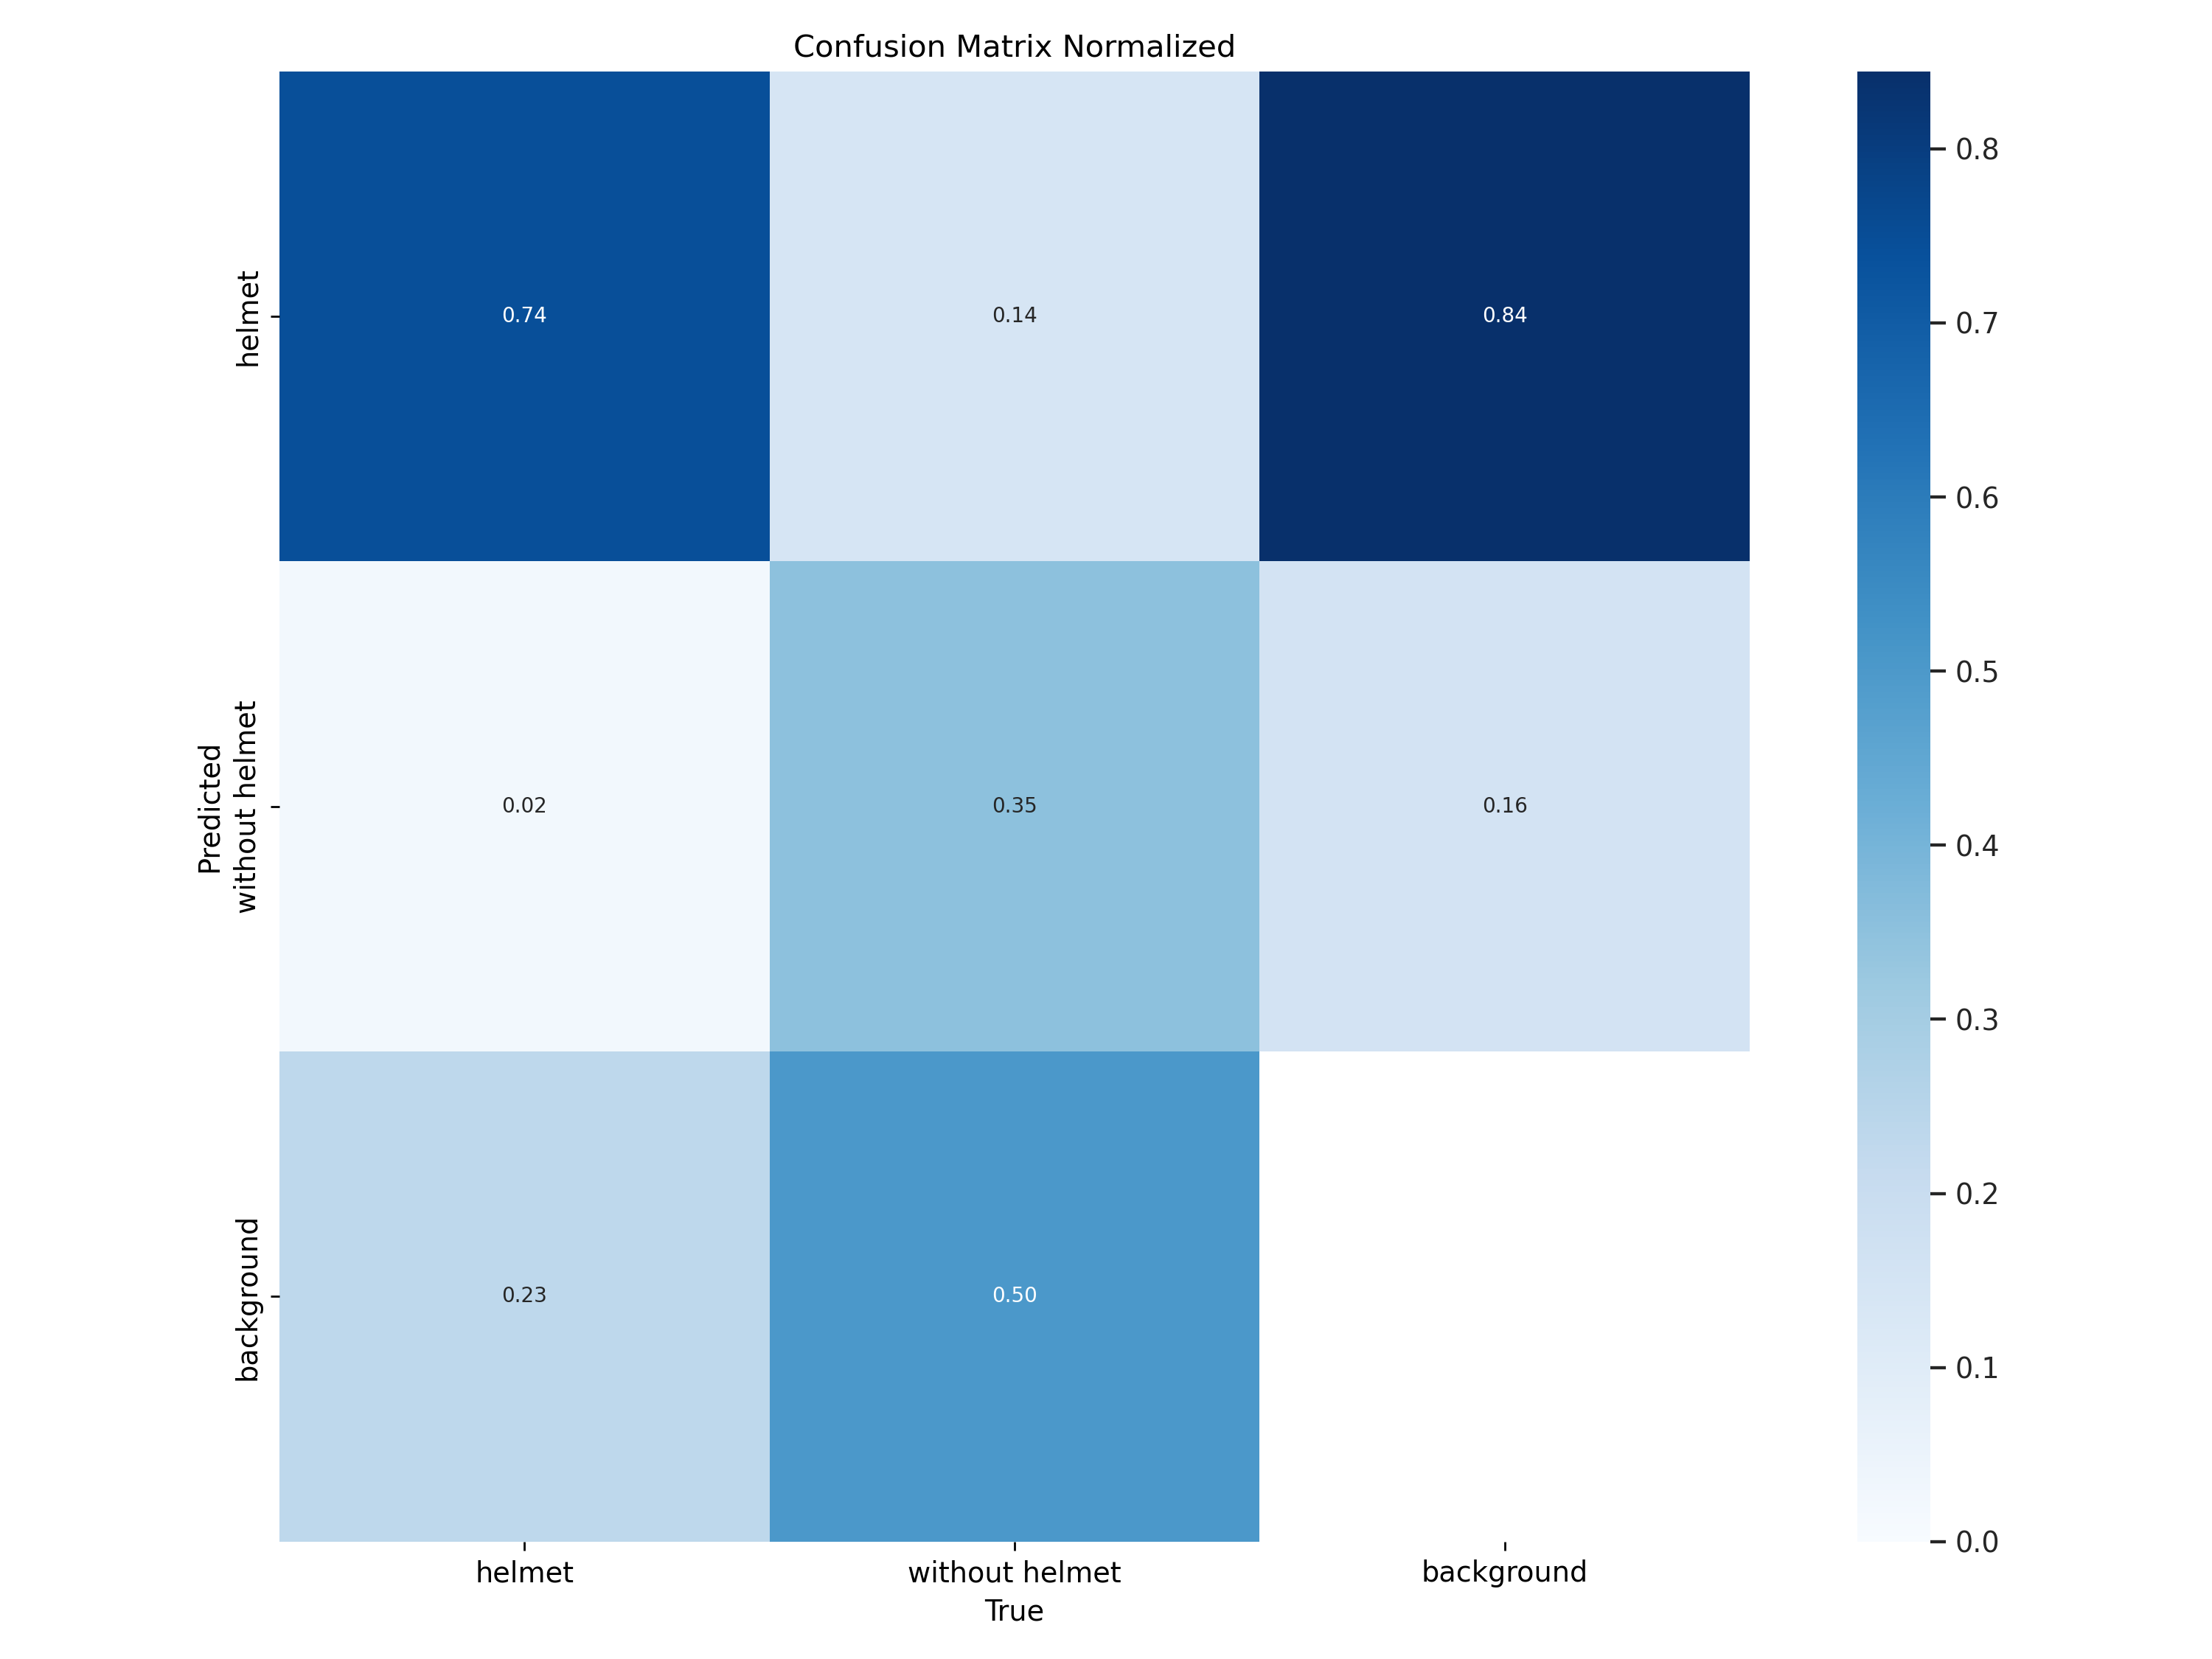

In [9]:
display(Markdown("TRAINING: Confusion Matrix Normalised"))
Image("/home/syssoni/Documents/Python/helmet_detection/yolov12/runs/detect/train10/confusion_matrix_normalized.png", width=800, height=800)

In [2]:
val_results = model.val(
    data="/home/syssoni/Documents/Python/helmet_detection/yolov12/helmet_detection-1/data.yaml",
    imgsz = 640,
    device = "0"
)

NameError: name 'model' is not defined

VALIDATION: Confusion Matrix

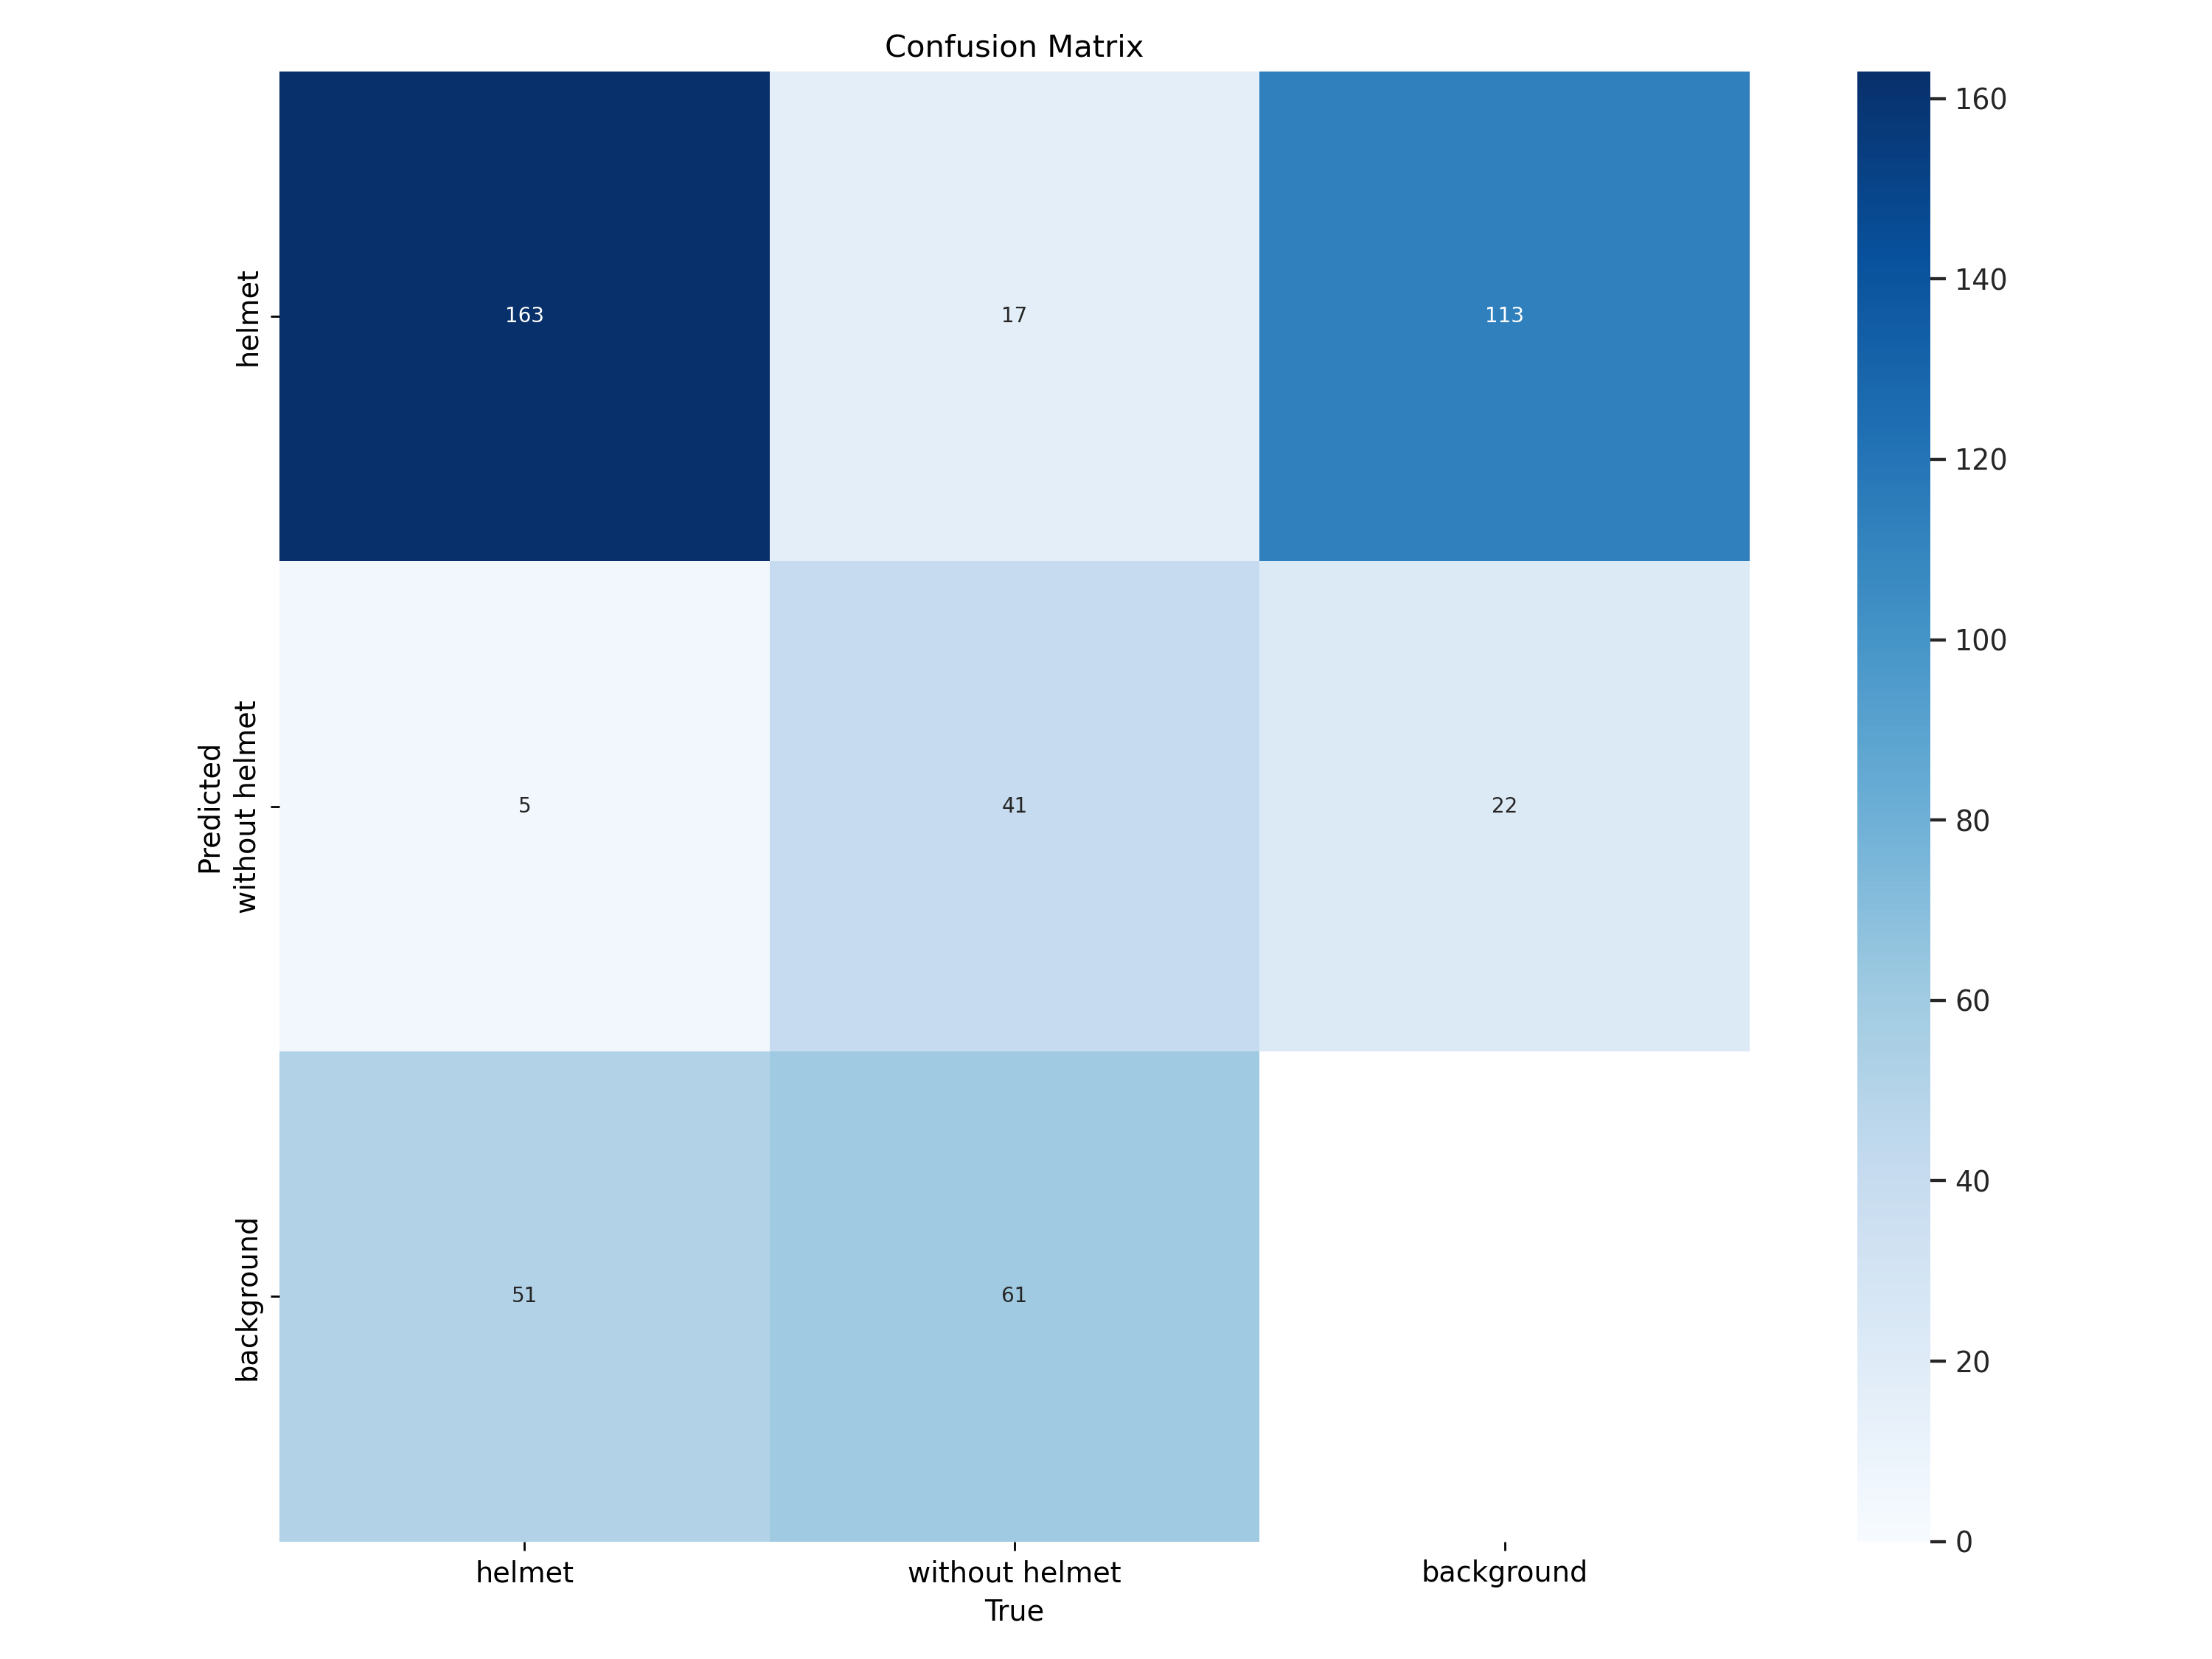

In [13]:
display(Markdown("VALIDATION: Confusion Matrix"))
Image("/home/syssoni/Documents/Python/helmet_detection/yolov12/runs/detect/train102/confusion_matrix.png", width=800, height=800)

VALIDATION: Confusion Matrix Normalised

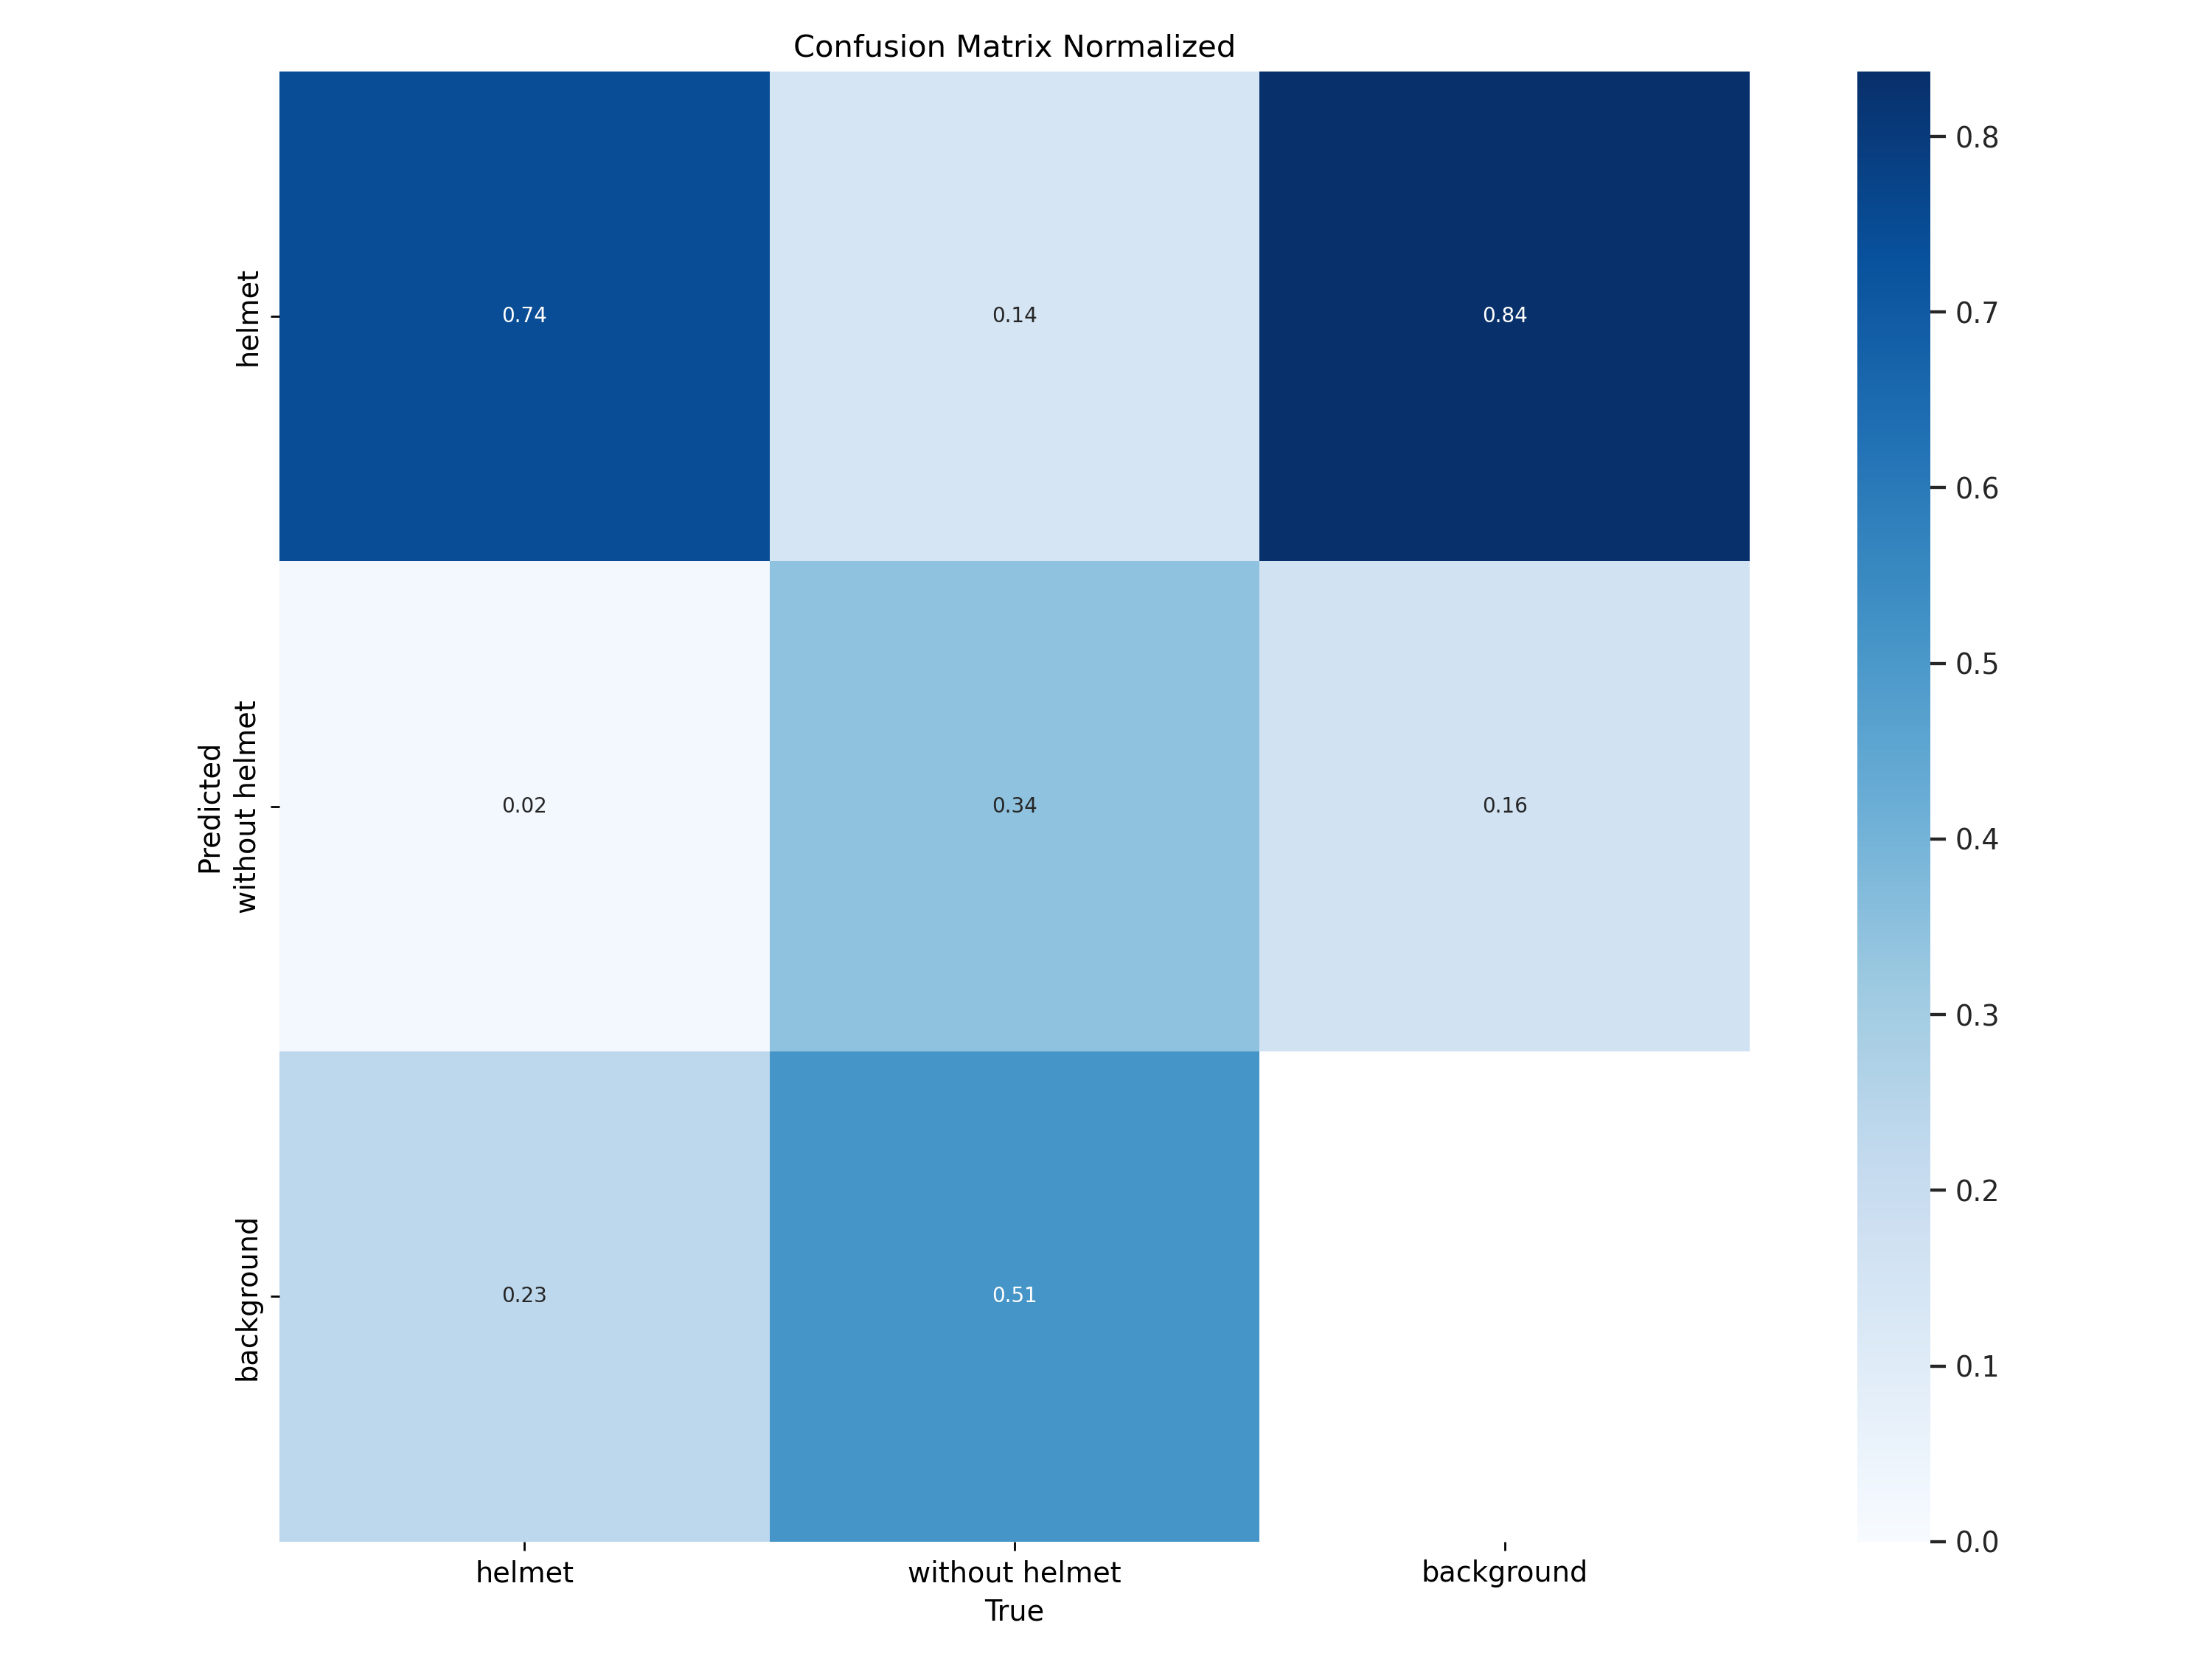

In [14]:
display(Markdown("VALIDATION: Confusion Matrix Normalised"))
Image("/home/syssoni/Documents/Python/helmet_detection/yolov12/runs/detect/train102/confusion_matrix_normalized.png", width=800, height=800)

In [16]:
test_results = model.val(
    data="/home/syssoni/Documents/Python/helmet_detection/yolov12/helmet_detection-1/data.yaml",
    split = "test",
    imgsz = 640,
    device = "0"
)

Ultralytics 8.3.96 🚀 Python-3.13.2 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3895MiB)


val: Scanning /home/syssoni/Documents/Python/helmet_detection/yolov12/helmet_detection-1/test/labels... 74 images, 0 backgrounds, 0 corrupt: 100%|██████████| 74/74 [00:00<00:00, 1881.64it/s]

val: New cache created: /home/syssoni/Documents/Python/helmet_detection/yolov12/helmet_detection-1/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  2.98it/s]


                   all         74        170      0.611      0.439      0.485      0.218
                helmet         50        107      0.491      0.607      0.561       0.26
        without helmet         30         63      0.732       0.27      0.408      0.176
Speed: 2.9ms preprocess, 10.9ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to runs/detect/train103


TESTING: Confusion Matrix

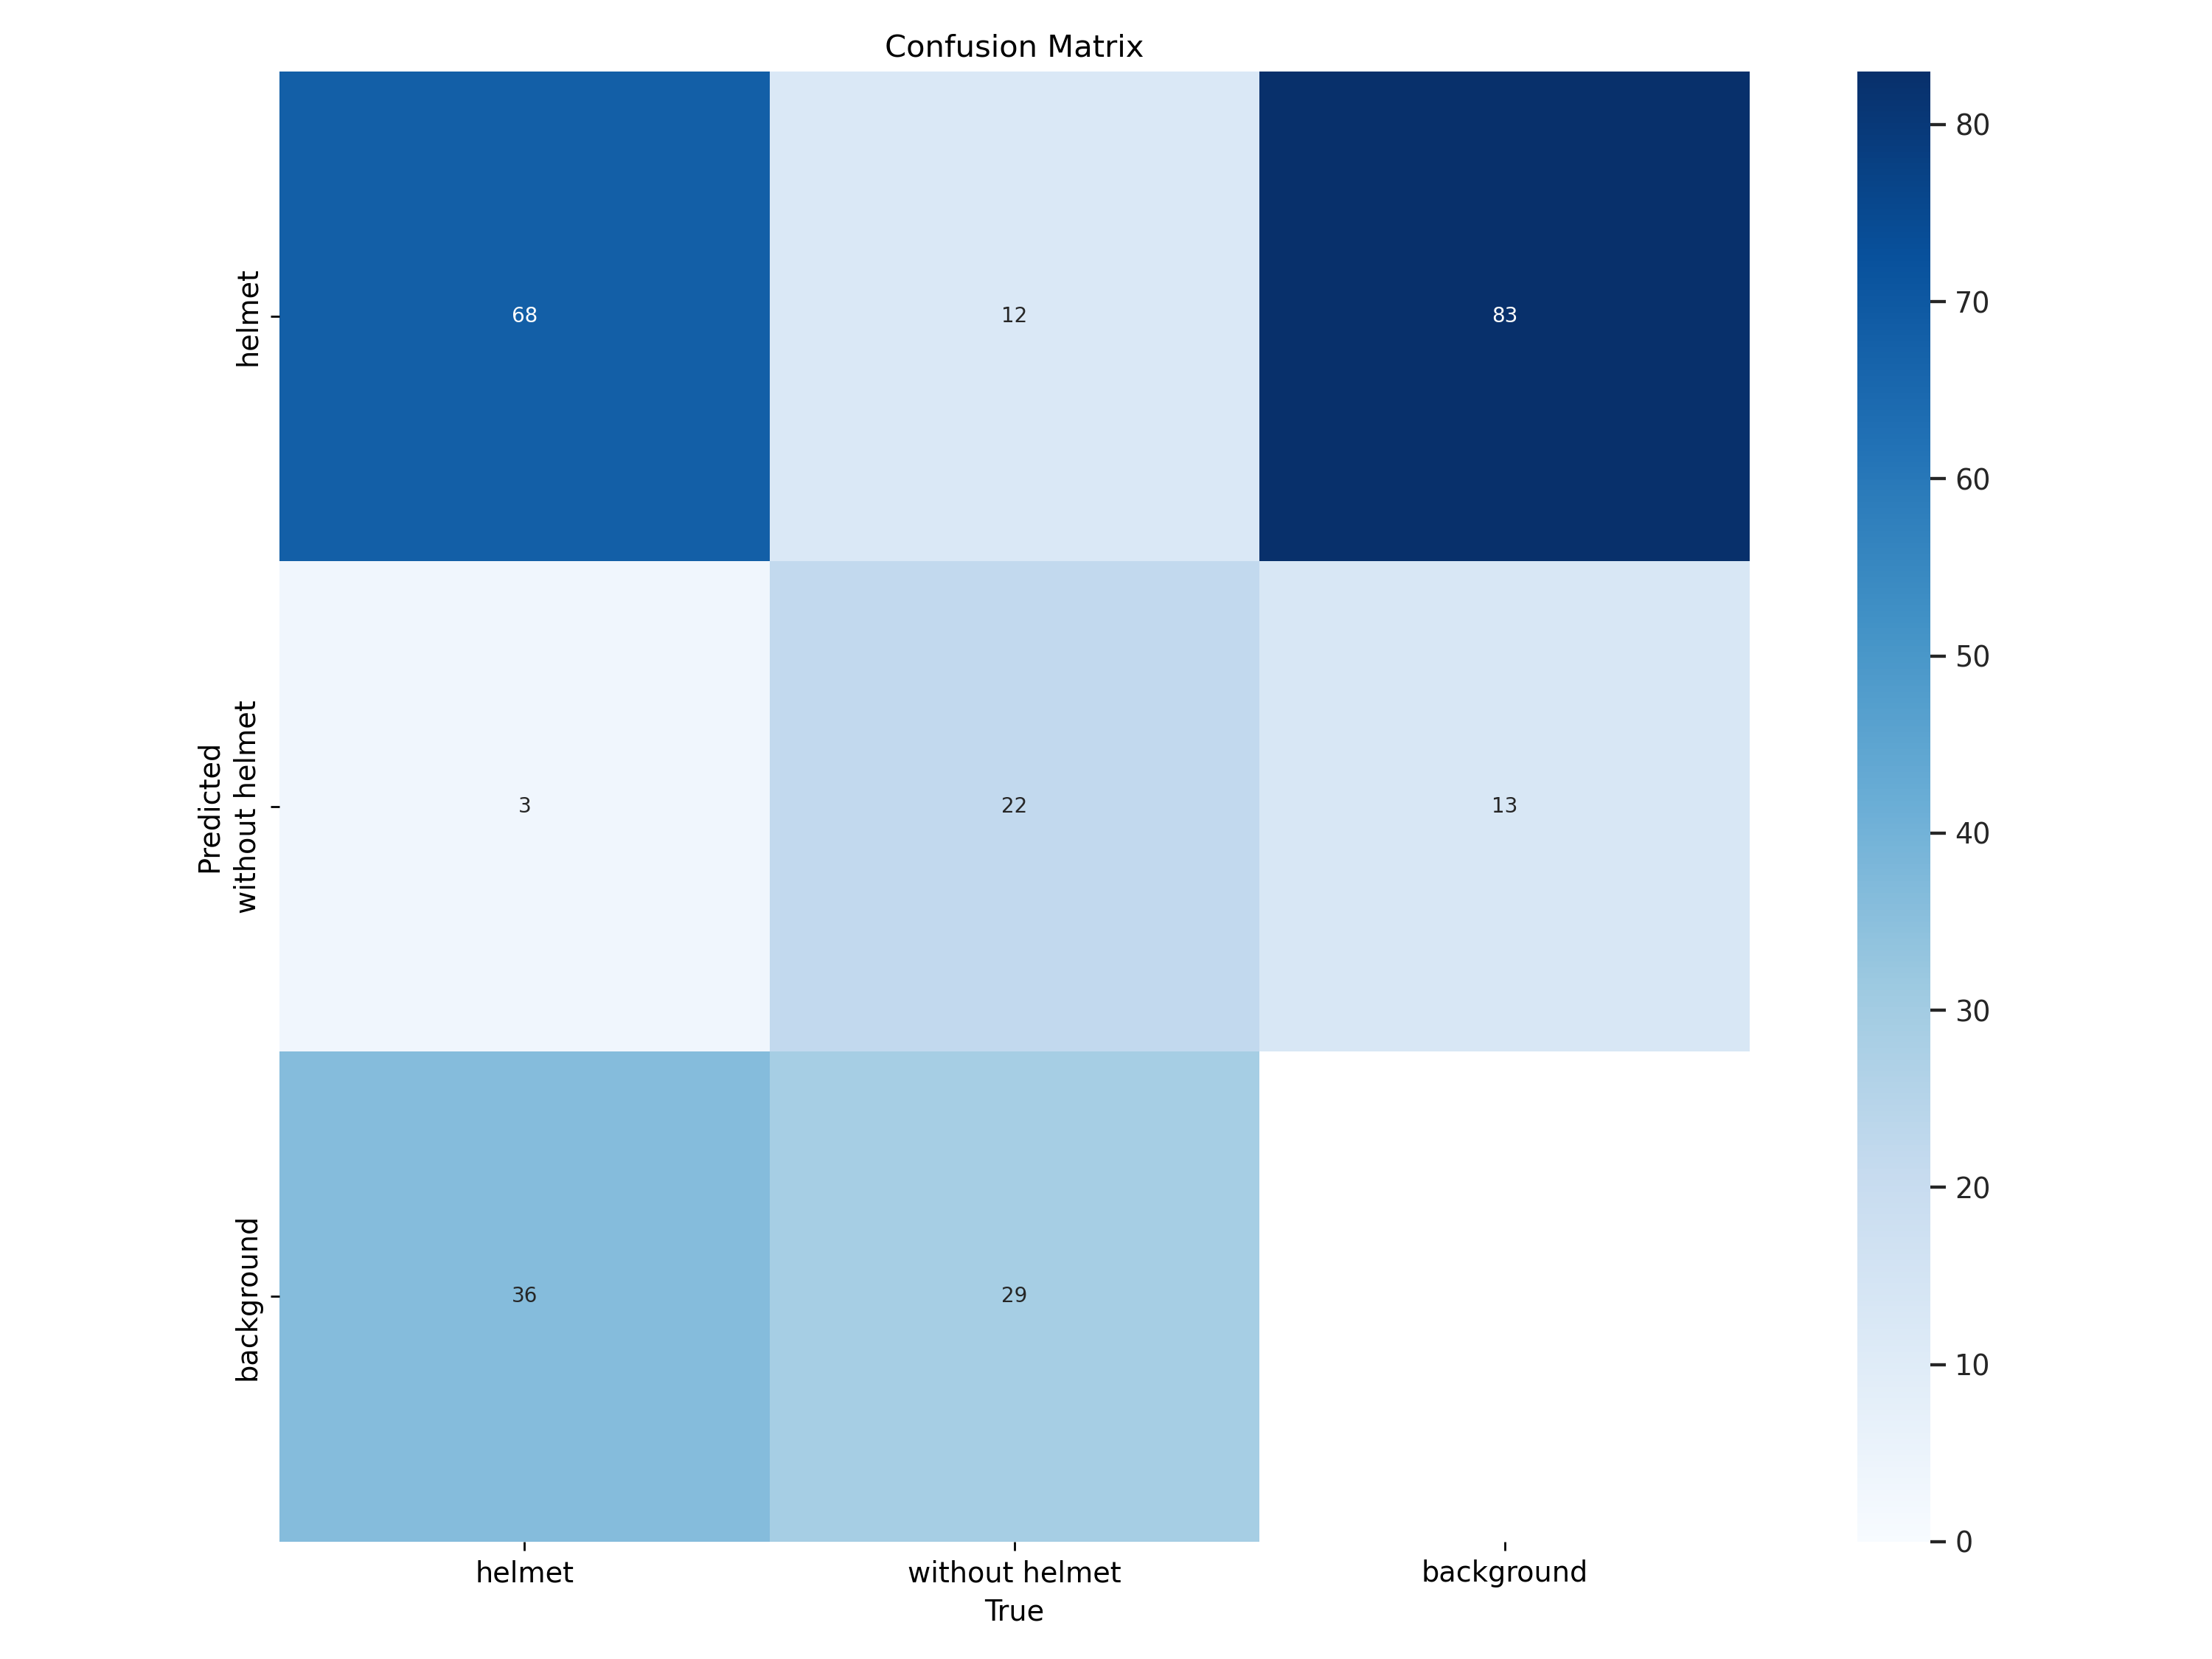

In [17]:
display(Markdown("TESTING: Confusion Matrix"))
Image("/home/syssoni/Documents/Python/helmet_detection/yolov12/runs/detect/train103/confusion_matrix.png", width=800, height=800)

TESTING: Confusion Matrix Normalised

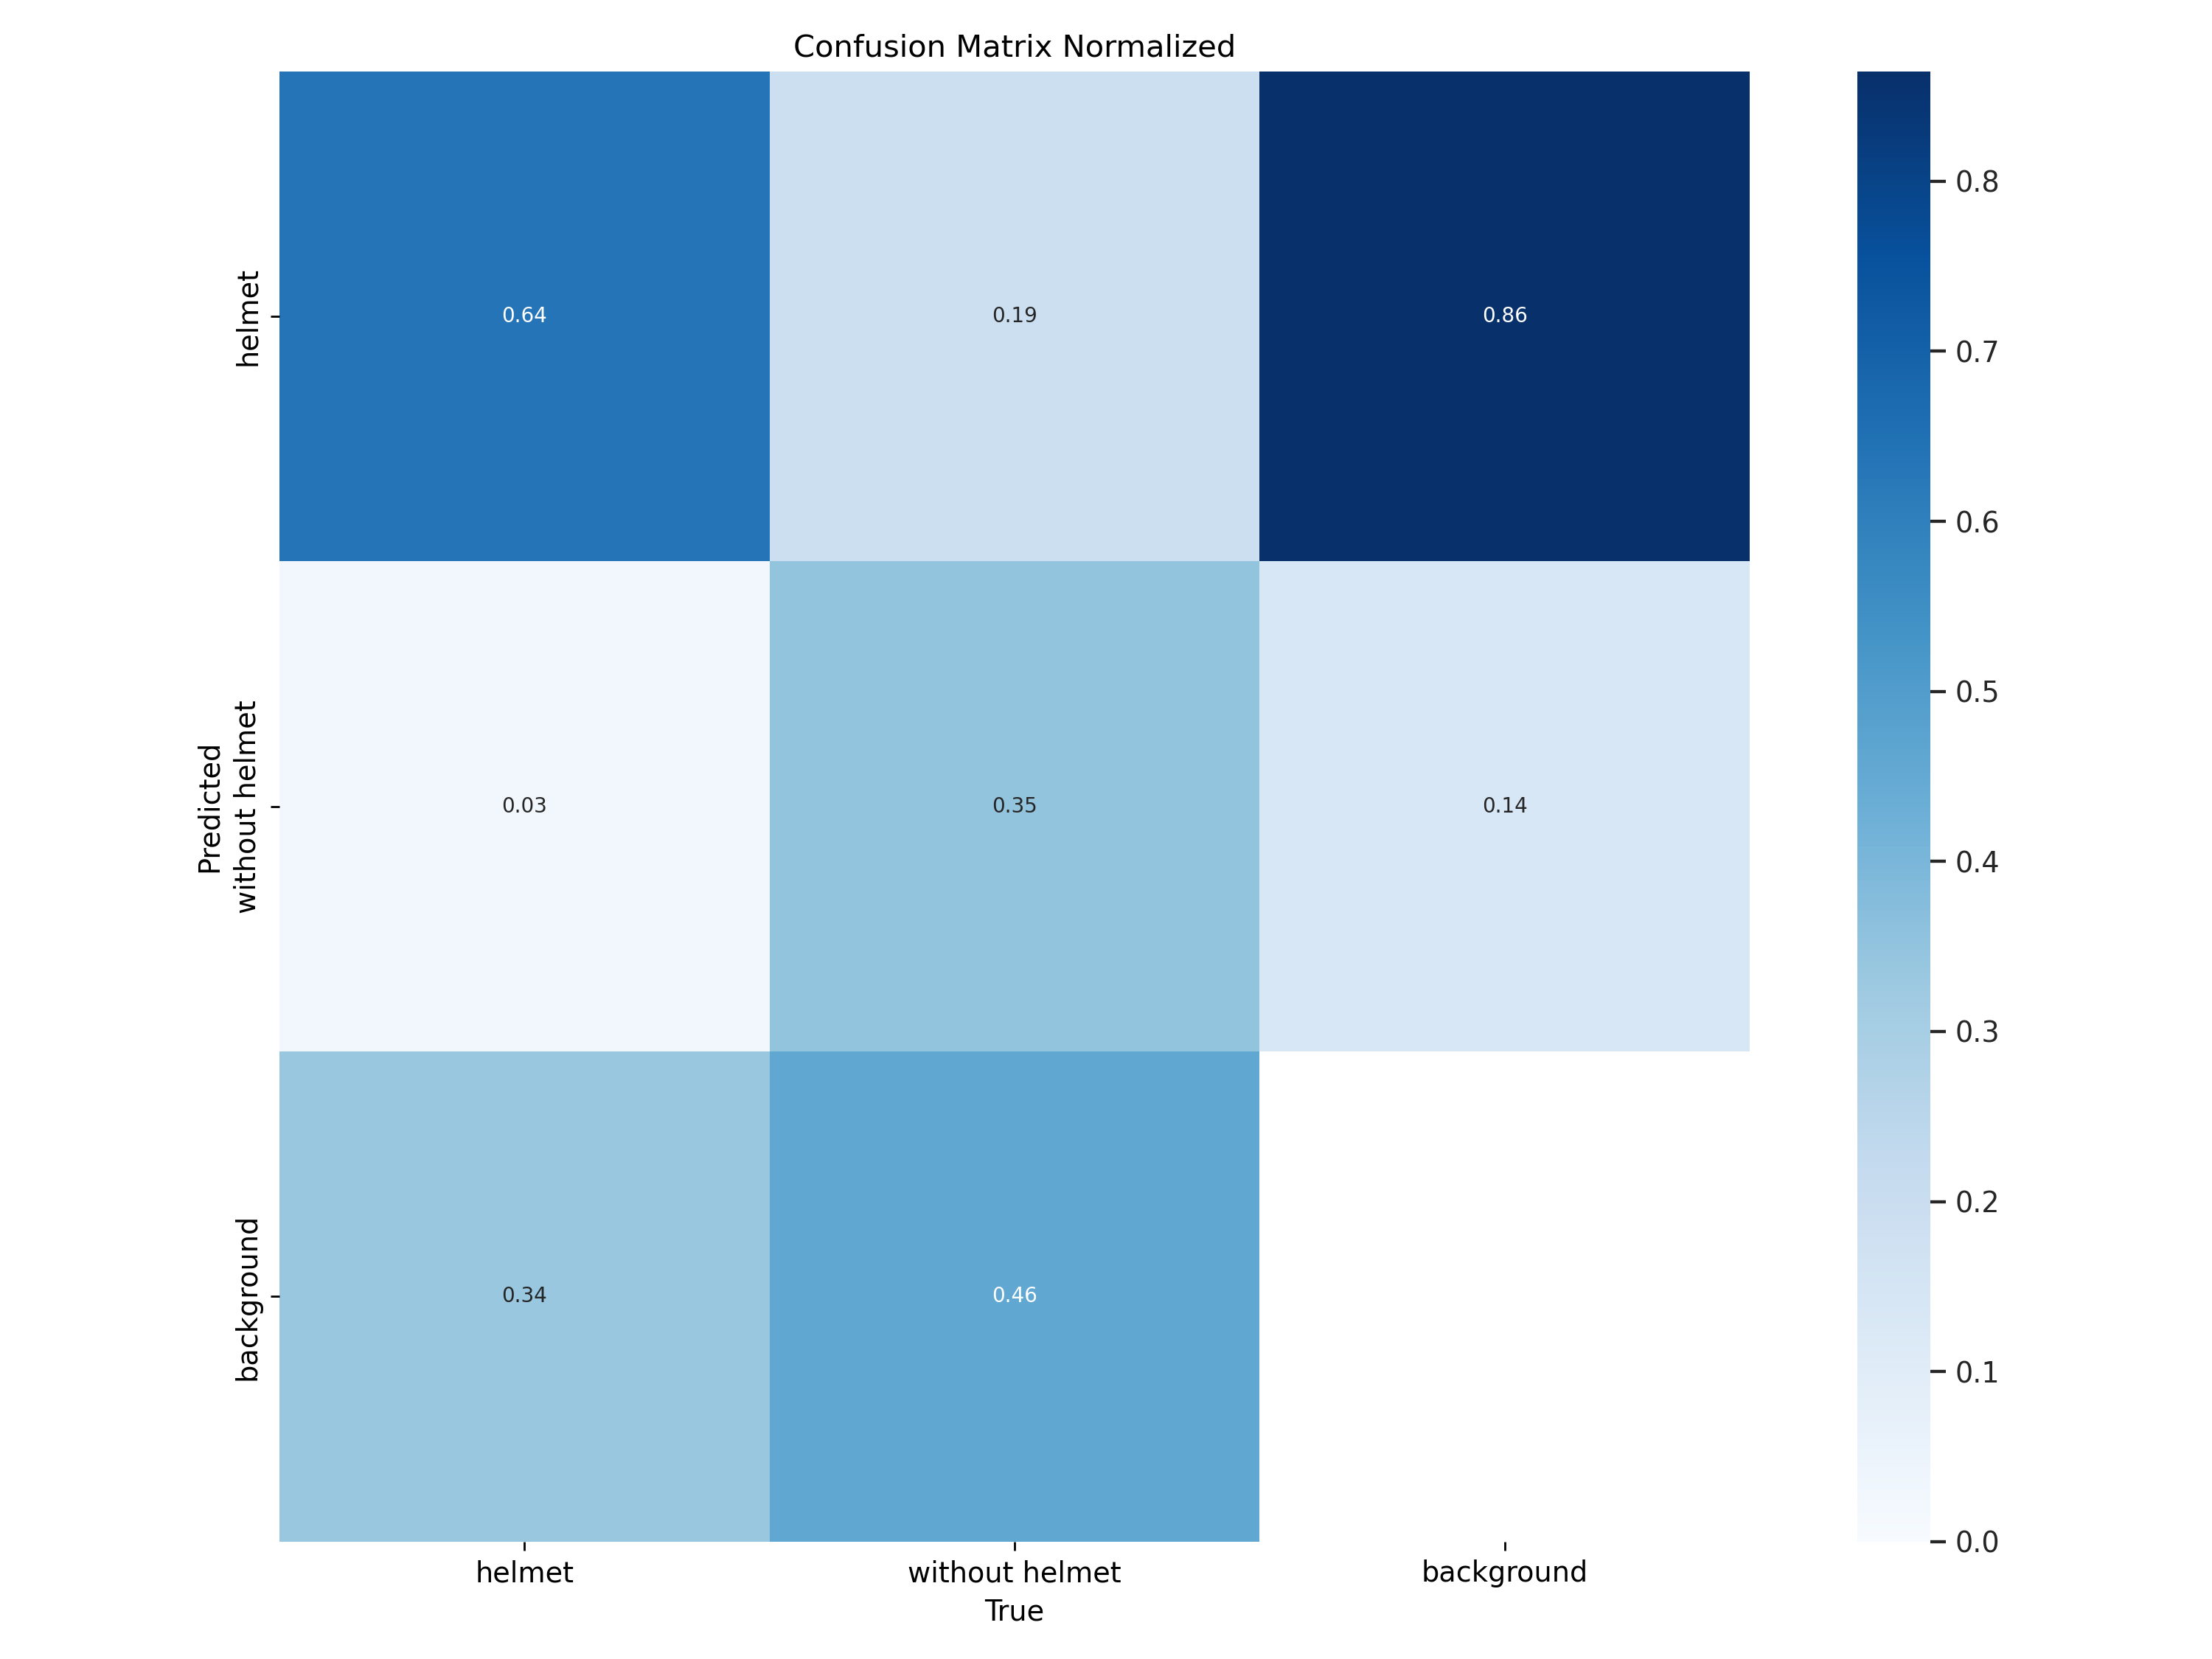

In [16]:
display(Markdown("TESTING: Confusion Matrix Normalised"))
Image("/home/syssoni/Documents/Python/helmet_detection/yolov12/runs/detect/train103/confusion_matrix_normalized.png", width=800, height=800)